# Ứng dụng 1 — Dự đoán tiểu đường

**Quy trình:** Data → Understand → Clean → Represent → Train → Validate → Test → Persist → Deploy

## 1. Bài toán và nguồn dữ liệu

- **Dataset:** Diabetes Prediction Dataset — https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset/data
- **Mục tiêu:** phân loại nhị phân nguy cơ tiểu đường (`diabetes`: 0/1).
- **Một quan sát:** một hồ sơ người bệnh tại một thời điểm.
- **Đặc trưng triển khai:** `age`, `bmi`, `hbA1c_level`, `blood_glucose_level`, `gender`, `smoking_history`.
- Các cột `year`, `location`, nhóm chủng tộc, `hypertension`, `heart_disease` được loại khỏi mô hình để đầu vào huấn luyện khớp chính xác với biểu mẫu/API đã triển khai. Đây là đánh đổi: giảm thông tin nhưng tránh training-serving skew và hạn chế sử dụng thuộc tính nhạy cảm.

Notebook dùng validation để so sánh 5 mô hình. Test được giữ kín đến sau khi chọn mô hình.

In [1]:
from pathlib import Path
import json, os, re, warnings
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-asg02")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ROOT = Path.cwd()
(ROOT / "models").mkdir(exist_ok=True)
(ROOT / "artifacts").mkdir(exist_ok=True)
(ROOT / "figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

## 2. Kiểm tra dữ liệu bắt buộc

In [2]:
df_raw = pd.read_csv(ROOT / "diabetes_dataset.csv")
print("shape:", df_raw.shape)
display(df_raw.head().T)
df_raw.info()
display(df_raw.describe(include="number").T[["count", "mean", "std", "min", "50%", "max"]].round(2))
display(df_raw.describe(exclude="number").T[["count", "unique", "top", "freq"]])
print("\nMissing values:\n", df_raw.isna().sum())
print("\nDuplicated records:", df_raw.duplicated().sum())
print("\nTarget distribution:\n", df_raw["diabetes"].value_counts())

shape: (100000, 16)


,0,1,2,3,4
year,2020,2015,2015,2015,2016
gender,Female,Female,Male,Male,Female
age,32.0,29.0,18.0,41.0,52.0
location,Alabama,Alabama,Alabama,Alabama,Alabama
race:AfricanAmerican,0,0,0,0,1
race:Asian,0,1,0,0,0
race:Caucasian,0,0,0,1,0
race:Hispanic,0,0,0,0,0
race:Other,1,0,1,0,0
hypertension,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  diabetes    

,count,mean,std,min,50%,max
year,100000.0,2018.36,1.35,2015.00,2019.00,2022.00
age,100000.0,41.89,22.52,0.08,43.00,80.00
race:AfricanAmerican,100000.0,0.20,0.40,0.00,0.00,1.00
race:Asian,100000.0,0.20,0.40,0.00,0.00,1.00
race:Caucasian,100000.0,0.20,0.40,0.00,0.00,1.00
race:Hispanic,100000.0,0.20,0.40,0.00,0.00,1.00
race:Other,100000.0,0.20,0.40,0.00,0.00,1.00
hypertension,100000.0,0.07,0.26,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,27.32,95.69


,count,unique,top,freq
gender,100000,3,Female,58552
location,100000,55,Hawaii,2038
smoking_history,100000,6,No Info,35816



Missing values:
 year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

Duplicated records: 14

Target distribution:
 diabetes
0    91500
1     8500
Name: count, dtype: int64


## 3. Làm sạch, chia dữ liệu và chống leakage

Bản ghi trùng hoàn toàn được loại **trước khi chia** để cùng một hồ sơ không xuất hiện ở cả train và test. Sau đó chia 70/15/15 có stratification. Imputer, scaler và one-hot encoder chỉ được `fit` trên train bên trong `Pipeline`.

In [3]:
features = ["age", "bmi", "hbA1c_level", "blood_glucose_level", "gender", "smoking_history"]
target = "diabetes"

df = df_raw[features + [target]].copy()
df["gender"] = df["gender"].astype("string").str.strip()
df["smoking_history"] = df["smoking_history"].astype("string").str.strip()
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before-len(df):,} exact duplicates; cleaned shape = {df.shape}")

X, y = df[features], df[target].astype(int)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print("train/validation/test:", X_train.shape, X_val.shape, X_test.shape)
print("positive rates:", y_train.mean().round(4), y_val.mean().round(4), y_test.mean().round(4))

Removed 4,345 exact duplicates; cleaned shape = (95655, 7)
train/validation/test: (66958, 6) (14348, 6) (14349, 6)
positive rates: 0.0885 0.0884 0.0885


## 4. EDA: quan sát → diễn giải → hàm ý ML

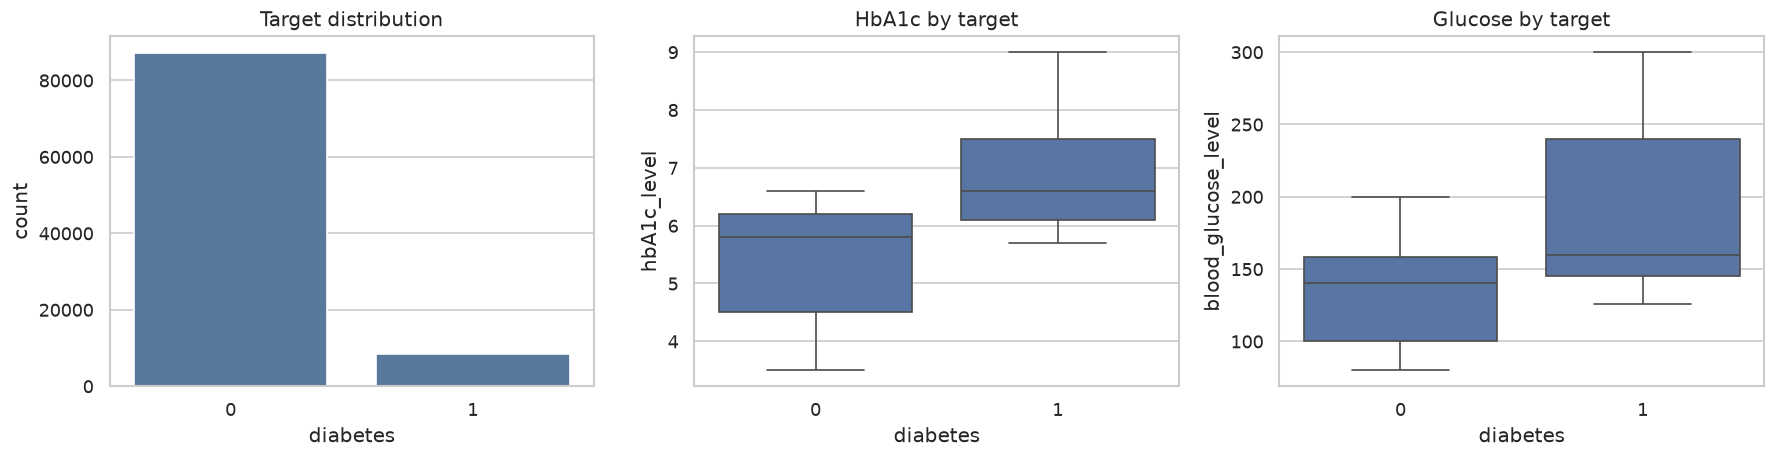

Observation: lớp 1 ít hơn rõ rệt; HbA1c và glucose của lớp 1 cao hơn.
Interpretation: accuracy đơn lẻ có thể che giấu false negative.
ML implication: dùng stratification, class_weight và ưu tiên Recall/F1 của lớp 1.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="diabetes", ax=axes[0], color="#4C78A8")
axes[0].set_title("Target distribution")
sns.boxplot(data=df.sample(min(30000, len(df)), random_state=RANDOM_STATE), x="diabetes", y="hbA1c_level", ax=axes[1])
axes[1].set_title("HbA1c by target")
sns.boxplot(data=df.sample(min(30000, len(df)), random_state=RANDOM_STATE), x="diabetes", y="blood_glucose_level", ax=axes[2])
axes[2].set_title("Glucose by target")
plt.tight_layout()
plt.savefig(ROOT / "figures/diabetes_eda.png", dpi=160, bbox_inches="tight")
plt.show()

print("Observation: lớp 1 ít hơn rõ rệt; HbA1c và glucose của lớp 1 cao hơn.")
print("Interpretation: accuracy đơn lẻ có thể che giấu false negative.")
print("ML implication: dùng stratification, class_weight và ưu tiên Recall/F1 của lớp 1.")

## 5. Biểu diễn dữ liệu

Một hồ sơ thô gồm 4 số + 2 biến phân loại. Sau điền khuyết, chuẩn hóa số và one-hot encoding, mỗi hồ sơ thành vector $x_i\in\mathbb{R}^d$; một batch có dạng $X\in\mathbb{R}^{B\times d}$. `handle_unknown='ignore'` giúp API nhận hạng mục hợp lệ mới mà không làm sai số chiều.

In [5]:
numeric_features = ["age", "bmi", "hbA1c_level", "blood_glucose_level"]
categorical_features = ["gender", "smoking_history"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

representation = clone(preprocessor).fit_transform(X_train)
print("Original record:")
display(X_train.head(1))
print("Raw feature shape:", X_train.shape)
print("Final numerical matrix:", representation.shape, representation.dtype)
print("One numerical vector (rounded):", np.round(representation[0], 3))

Original record:


,age,bmi,hbA1c_level,blood_glucose_level,gender,smoking_history
29820,22.0,21.69,6.2,158,Female,never


Raw feature shape: (66958, 6)
Final numerical matrix: (66958, 13) float64
One numerical vector (rounded): [-0.875 -0.831  0.62   0.481  1.     0.     0.     0.     0.     0.
  0.     1.     0.   ]


## 6. So sánh 5 mô hình trên validation

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=120, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=-1),
}

def score_binary(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    score = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_eval)
    return {
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision_1": precision_score(y_eval, pred, zero_division=0),
        "Recall_1": recall_score(y_eval, pred, zero_division=0),
        "F1_1": f1_score(y_eval, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, score),
    }

rows, fitted = [], {}
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    rows.append({"Model": name, **score_binary(pipe, X_val, y_val)})

comparison = pd.DataFrame(rows).sort_values(["F1_1", "Recall_1"], ascending=False).reset_index(drop=True)
display(comparison.style.format({c: "{:.4f}" for c in comparison.columns if c != "Model"}))
comparison.to_csv(ROOT / "artifacts/diabetes_validation_metrics.csv", index=False)
selected_name = comparison.loc[0, "Model"]
print("Selected by validation F1_1:", selected_name)

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Random Forest,0.9643,0.8534,0.7203,0.7812,0.9710
1,KNN,0.9599,0.9316,0.5902,0.7226,0.9329
2,Decision Tree,0.8908,0.4430,0.9125,0.5964,0.9722
3,Logistic Regression,0.8796,0.4148,0.8802,0.5639,0.9588
4,Linear SVM,0.8795,0.4145,0.8786,0.5633,0.9588


Selected by validation F1_1: Random Forest


## 7. Refit train+validation, test đúng một lần và lưu pipeline

FINAL TEST METRICS


,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,0.9615,0.8306,0.7102,0.7657,0.9689


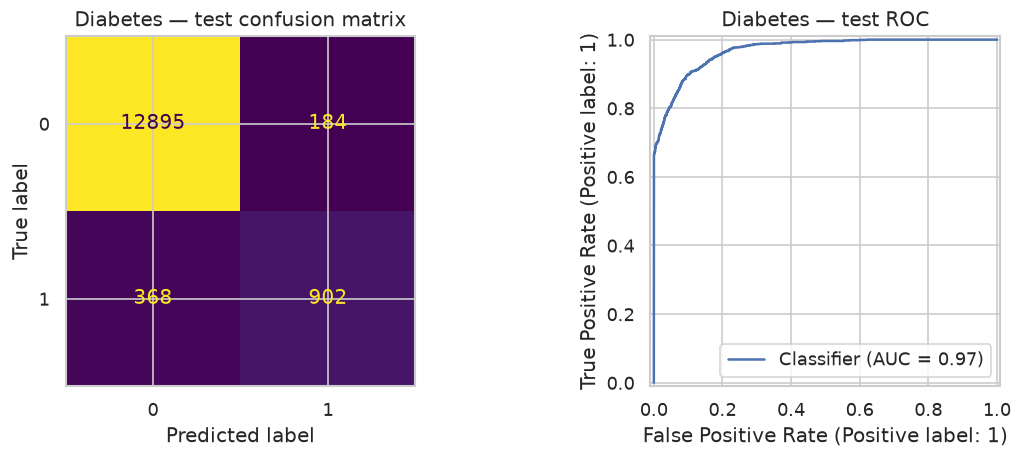

TN=12895, FP=184, FN=368, TP=902. FN là ca bệnh bị bỏ sót nên cần theo dõi đặc biệt.
Saved models/diabetes_pipeline.joblib and metadata.


In [7]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", clone(models[selected_name])),
])
final_pipeline.fit(X_trainval, y_trainval)
test_metrics = score_binary(final_pipeline, X_test, y_test)
print("FINAL TEST METRICS")
display(pd.DataFrame([test_metrics]).style.format("{:.4f}"))

test_pred = final_pipeline.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Diabetes — test confusion matrix")
if hasattr(final_pipeline, "predict_proba"):
    RocCurveDisplay.from_predictions(y_test, final_pipeline.predict_proba(X_test)[:, 1], ax=axes[1])
else:
    RocCurveDisplay.from_predictions(y_test, final_pipeline.decision_function(X_test), ax=axes[1])
axes[1].set_title("Diabetes — test ROC")
plt.tight_layout()
plt.savefig(ROOT / "figures/diabetes_test_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}. FN là ca bệnh bị bỏ sót nên cần theo dõi đặc biệt.")

joblib.dump(final_pipeline, ROOT / "models/diabetes_pipeline.joblib", compress=3)
metadata = {
    "application": "diabetes", "selected_model": selected_name, "raw_features": features,
    "split": "70/15/15 stratified; model selection on validation; one final test evaluation",
    "selection_metric": "F1 positive class", "test_metrics": test_metrics,
    "final_input_shape": [int(len(X_trainval)), int(final_pipeline.named_steps["preprocess"].transform(X_trainval.head(1)).shape[1])],
    "random_state": RANDOM_STATE,
}
(ROOT / "models/diabetes_metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved models/diabetes_pipeline.joblib and metadata.")